# **8-Rook Problem**

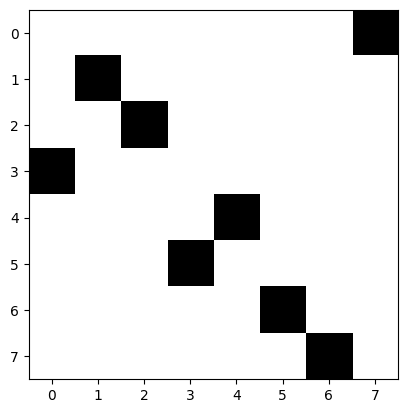

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_initial_state(state):
    placed_positions = []
    i = 0
    while i < 8:
        pos = np.random.randint(low=0, high=64)
        if pos not in placed_positions:
            placed_positions.append(pos)
            i += 1
    for pos in placed_positions:
        state[pos // 8][pos % 8] = 1

def calculate_energy(state):
    energy_col = 0
    energy_row = 0
    for col in range(8):
        col_sum = sum(state[row][col] for row in range(8)) - 1
        energy_col += col_sum ** 2
    for row in range(8):
        row_sum = sum(state[row][col] for col in range(8)) - 1
        energy_row += row_sum ** 2
    return energy_col + energy_row

def attempt_flip(curr_energy, state):
    while True:
        pos1 = np.random.randint(low=0, high=64)
        pos2 = np.random.randint(low=0, high=64)
        if state[pos1 // 8][pos1 % 8] != 1 and state[pos2 // 8][pos2 % 8] != 0:
            continue
        if state[pos1 // 8][pos1 % 8] == 1 and state[pos2 // 8][pos2 % 8] == 0:
            state[pos1 // 8][pos1 % 8] = 0
            state[pos2 // 8][pos2 % 8] = 1
            new_energy = calculate_energy(state)
            if curr_energy > new_energy:
                curr_energy = new_energy
            else:
                state[pos1 // 8][pos1 % 8] = 1
                state[pos2 // 8][pos2 % 8] = 0
            break
    return curr_energy

initial_state = np.zeros((8, 8))
generate_initial_state(initial_state)
plt.imshow(initial_state, cmap='binary', interpolation='nearest')
curr_energy = calculate_energy(initial_state)

iterations = 1000
for i in range(iterations):
    curr_energy = attempt_flip(curr_energy, initial_state)
    plt.imshow(initial_state, cmap='binary', interpolation='nearest')

# **TSP (Traveling Salesman Problem)**

Optimal Tour:
Start from D
Go to B
Go to H
Go to E
Go to F
Go to J
Go to G
Go to A
Go to I
Go to C
Return to D
Minimum Path Cost: 145.72863571301713


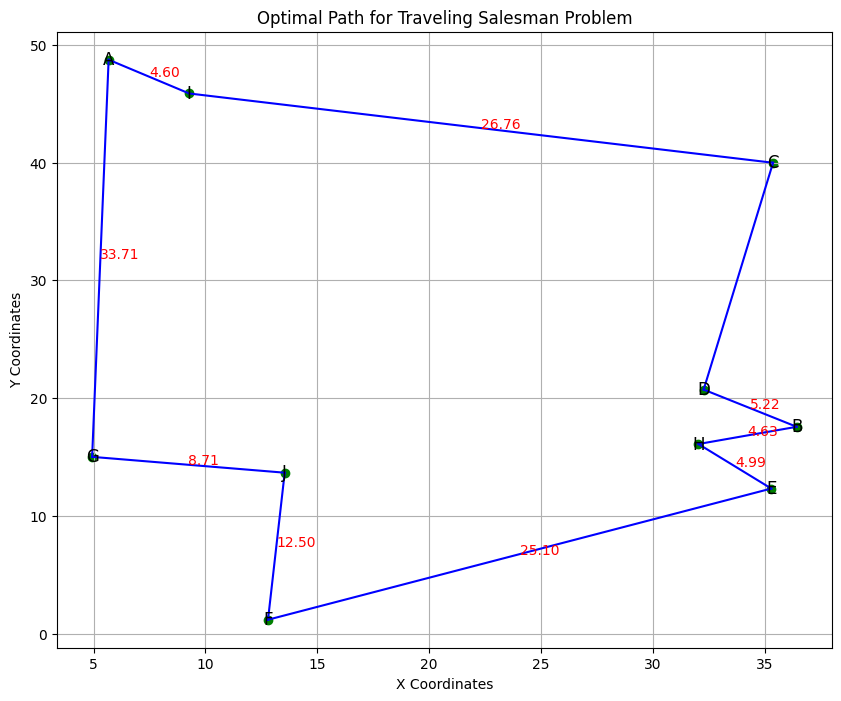

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define cities with new names and coordinates
cities = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']

# Generate random coordinates for the cities
np.random.seed(47)
coordinates = {city: np.random.rand(2) * 50 for city in cities}

# Calculate pairwise distances between cities
def compute_distances(cities):
    num_cities = len(cities)
    distance_matrix = np.zeros((num_cities, num_cities))
    for i, city_1 in enumerate(cities):
        for j, city_2 in enumerate(cities):
            if i != j:
                distance_matrix[i, j] = np.linalg.norm(coordinates[city_1] - coordinates[city_2])
    return distance_matrix

# TSP solution class
class TSPProblem:
    def __init__(self, cities, distance_matrix):
        self.cities = cities
        self.num_cities = len(cities)
        self.distance_matrix = distance_matrix
        self.cost_matrix = np.zeros((self.num_cities, self.num_cities))
        self.set_up_cost_matrix()

    def set_up_cost_matrix(self):
        for i in range(self.num_cities):
            for j in range(self.num_cities):
                if i != j:
                    self.cost_matrix[i, j] = -self.distance_matrix[i, j]

    def total_distance(self, tour):
        total_dist = 0
        for i in range(self.num_cities - 1):
            total_dist += self.distance_matrix[tour[i], tour[i + 1]]
        total_dist += self.distance_matrix[tour[-1], tour[0]]  # Return to start city
        return total_dist

    def find_best_tour(self, iterations=100000):
        min_cost = float('inf')
        best_tour = None
        tour = np.random.permutation(self.num_cities)
        for _ in range(iterations):
            i, j = np.random.choice(self.num_cities, 2, replace=False)
            energy_change = 2 * (self.cost_matrix[i].dot(tour) * tour[i] + self.cost_matrix[j].dot(tour) * tour[j])
            if energy_change < 0:
                tour[i], tour[j] = tour[j], tour[i]
                cost = self.total_distance(tour)
                if cost < min_cost:
                    min_cost = cost
                    best_tour = tour.copy()
        return best_tour, min_cost

# Compute the distance matrix
distances = compute_distances(cities)

# Create an instance of TSP Problem
tsp = TSPProblem(cities, distances)

# Solve the TSP
optimal_route, min_route_cost = tsp.find_best_tour()

# Display the optimal route and cost
print("Optimal Tour:")
for i, city_idx in enumerate(optimal_route):
    if i == 0:
        print(f"Start from {cities[city_idx]}")
    else:
        print(f"Go to {cities[city_idx]}")
print(f"Return to {cities[optimal_route[0]]}")

# Display the minimum route cost
print("Minimum Path Cost:", min_route_cost)

# Plot cities and the optimal route
plt.figure(figsize=(10, 8))
for city in cities:
    plt.scatter(coordinates[city][0], coordinates[city][1], color='green')
    plt.text(coordinates[city][0], coordinates[city][1], city, ha='center', va='center', fontsize=12)

# Plot the optimal route
for i in range(len(optimal_route) - 1):
    plt.plot([coordinates[cities[optimal_route[i]]][0], coordinates[cities[optimal_route[i + 1]]][0]],
             [coordinates[cities[optimal_route[i]]][1], coordinates[cities[optimal_route[i + 1]]][1]],
             color='blue')

# Complete the cycle by connecting the last city to the first
plt.plot([coordinates[cities[optimal_route[-1]]][0], coordinates[cities[optimal_route[0]]][0]],
         [coordinates[cities[optimal_route[-1]]][1], coordinates[cities[optimal_route[0]]][1]],
         color='blue')

for i in range(len(optimal_route) - 1):
    mid_x = (coordinates[cities[optimal_route[i]]][0] + coordinates[cities[optimal_route[i + 1]]][0]) / 2
    mid_y = (coordinates[cities[optimal_route[i]]][1] + coordinates[cities[optimal_route[i + 1]]][1]) / 2
    plt.text(mid_x, mid_y, f'{distances[optimal_route[i], optimal_route[i + 1]]:.2f}', color='red')

plt.title("Optimal Path for Traveling Salesman Problem")
plt.xlabel("X Coordinates")
plt.ylabel("Y Coordinates")
plt.grid(True)
plt.show()